## Individual Homework


### Imports


In [182]:
# 1. Imports
import gzip
import os
import random
import shutil
import urllib.request
from collections import Counter
from itertools import product

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import torch
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import ParameterGrid, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from torch_geometric.data import Data
from torch_geometric.nn import GATConv, GATv2Conv, GCNConv, SAGEConv
from torch_geometric.utils import from_networkx, to_undirected


### Graph Loading


In [183]:
os.makedirs("data", exist_ok=True)

urls = {
    "edges": "https://snap.stanford.edu/data/email-Eu-core.txt.gz",
    "labels": "https://snap.stanford.edu/data/email-Eu-core-department-labels.txt.gz",
}

for name, url in urls.items():
    gz_path = f"data/{name}.gz"
    txt_path = f"data/{name}.txt"

    if not os.path.exists(txt_path):
        urllib.request.urlretrieve(url, gz_path)
        with gzip.open(gz_path, "rb") as f_in, open(txt_path, "wb") as f_out:
            shutil.copyfileobj(f_in, f_out)


In [184]:
edges = pd.read_csv(
    "data/edges.txt",
    sep=" ",
    header=None,
    names=["source", "target"],
)
labels = pd.read_csv(
    "data/labels.txt",
    sep=" ",
    header=None,
    names=["node", "department"],
)

print(edges.head())
print(labels.head())

print("Nodes:", labels["node"].nunique())
print("Edges:", len(edges))
print("Classes:", labels["department"].nunique())


   source  target
0       0       1
1       2       3
2       2       4
3       5       6
4       5       7
   node  department
0     0           1
1     1           1
2     2          21
3     3          21
4     4          21
Nodes: 1005
Edges: 25571
Classes: 42


### Task Definition: Node Classification

This notebook solves a **semi-supervised node classification** task on the SNAP Email-Eu-core communication network.

The graph represents email communication inside a European research institution. Each node corresponds to an employee/email account, and each directed edge represents an email communication link from one employee to another. Each labeled node has a department identifier, which is used as the target class.

The goal is to predict the **department/class label of each node** using the graph topology and engineered node features. The task is semi-supervised because only a subset of labeled nodes is used for training, while validation and test nodes are kept unseen during model fitting.

Formally:
- **Input:** graph structure, node-level structural features, and training labels for a subset of nodes.
- **Output:** predicted department label for each validation/test node.
- **Learning setup:** transductive node classification on a single graph.
- **Evaluation:** accuracy, macro F1, weighted F1, confusion matrix, and classification report on train/validation/test splits.

The notebook compares classical machine-learning baselines with graph neural network architectures such as **GCN**, **GraphSAGE**, **GAT**, and **GATv2**, including tuned and ensembled variants.


### Graph Building And Calculating Statistics


In [185]:
G = nx.from_pandas_edgelist(
    edges,
    source="source",
    target="target",
    create_using=nx.DiGraph(),
)

self_loop_edges = list(nx.selfloop_edges(G))
if self_loop_edges:
    G.remove_edges_from(self_loop_edges)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Removed self-loops:", len(self_loop_edges))
print("Is directed:", G.is_directed())
print("Is weakly connected:", nx.is_weakly_connected(G))
print("Number of weakly connected components:", nx.number_weakly_connected_components(G))
print("Number of strongly connected components:", nx.number_strongly_connected_components(G))

largest_cc = max(nx.weakly_connected_components(G), key=len)
subG = G.subgraph(list(largest_cc)).to_undirected()
subG.remove_edges_from(nx.selfloop_edges(subG))
centrality = nx.degree_centrality(G)

print("Largest component size:", len(largest_cc))
print("Approx diameter:", nx.diameter(subG))
print(
    "Top 5 nodes by centrality:",
    sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:5],
)


Number of nodes: 1005
Number of edges: 24929
Removed self-loops: 642
Is directed: True
Is weakly connected: False
Number of weakly connected components: 20
Number of strongly connected components: 203
Largest component size: 986
Approx diameter: 7
Top 5 nodes by centrality: [(160, 0.5418326693227091), (121, 0.3754980079681275), (107, 0.3695219123505976), (62, 0.3655378486055777), (86, 0.35258964143426297)]


In [186]:
degrees = dict(G.degree())
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())

print("Average degree:", sum(degrees.values()) / len(degrees))
print("Average in-degree:", sum(in_degrees.values()) / len(in_degrees))
print("Average out-degree:", sum(out_degrees.values()) / len(out_degrees))

G_undirected = G.to_undirected()
G_undirected.remove_edges_from(nx.selfloop_edges(G_undirected))

print("Average clustering coefficient:", nx.average_clustering(G_undirected))
print("Density:", nx.density(G))


Average degree: 49.60995024875622
Average in-degree: 24.80497512437811
Average out-degree: 24.80497512437811
Average clustering coefficient: 0.3993549664221539
Density: 0.024706150522288955


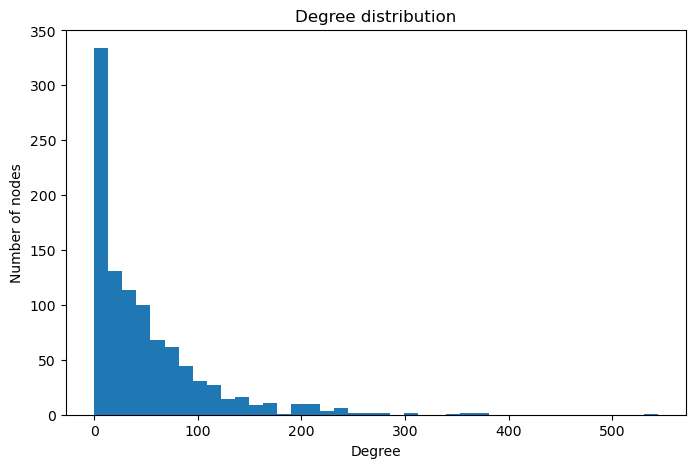

In [187]:
degree_values = list(degrees.values())

plt.figure(figsize=(8, 5))
plt.hist(degree_values, bins=40)
plt.title("Degree distribution")
plt.xlabel("Degree")
plt.ylabel("Number of nodes")
plt.show()


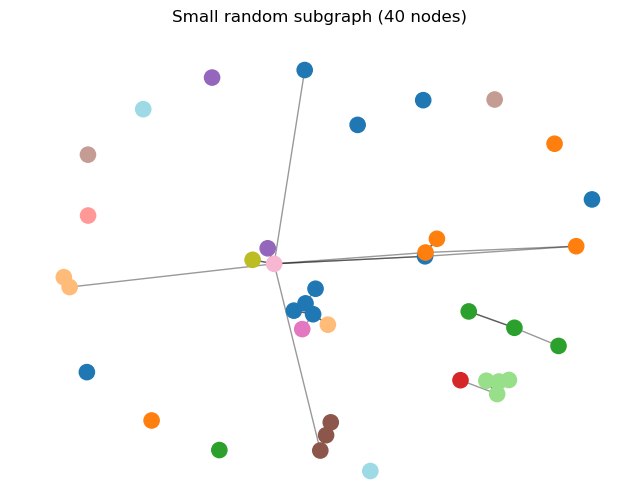

In [188]:
sample_nodes = random.sample(list(G.nodes()), 40)
subG = G.subgraph(sample_nodes).copy()

node_to_label = dict(zip(labels["node"], labels["department"]))
sub_node_colors = [node_to_label.get(node, -1) for node in subG.nodes()]

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(subG, seed=42)

nx.draw_networkx_nodes(
    subG,
    pos,
    node_size=120,
    node_color=sub_node_colors,
    cmap=plt.cm.tab20,
)
nx.draw_networkx_edges(subG, pos, alpha=0.4, arrows=False)

plt.title("Small random subgraph (40 nodes)")
plt.axis("off")
plt.show()


In [189]:
all_nodes = sorted(labels["node"].unique())
node_id_to_idx = {node_id: idx for idx, node_id in enumerate(all_nodes)}

edge_pairs = [
    [node_id_to_idx[src], node_id_to_idx[dst]]
    for src, dst in edges.values
    if src != dst
]

edge_index_directed = torch.tensor(edge_pairs, dtype=torch.long).t().contiguous()

# For department classification, communication in either direction is useful signal.
# Keep G directed for feature engineering, but use undirected edges for GNN message passing.
edge_index = to_undirected(edge_index_directed, num_nodes=len(all_nodes))

labels_sorted = labels.sort_values("node")
y = torch.tensor(labels_sorted["department"].values, dtype=torch.long)

print("directed edge_index shape:", edge_index_directed.shape)
print("message-passing edge_index shape:", edge_index.shape)
print("y shape:", y.shape)
print("Number of classes:", y.max().item() + 1)


directed edge_index shape: torch.Size([2, 24929])
message-passing edge_index shape: torch.Size([2, 32128])
y shape: torch.Size([1005])
Number of classes: 42


In [190]:
num_nodes = len(all_nodes)
G.remove_edges_from(nx.selfloop_edges(G))
G_undirected = G.to_undirected()
G_undirected.remove_edges_from(nx.selfloop_edges(G_undirected))

in_deg = torch.zeros(num_nodes, dtype=torch.float)
out_deg = torch.zeros(num_nodes, dtype=torch.float)
reciprocal_deg = torch.zeros(num_nodes, dtype=torch.float)
edge_set = set((src, dst) for src, dst in edges[["source", "target"]].values.tolist() if src != dst)

for src, dst in edges.values:
    if src == dst:
        continue
    src_idx = node_id_to_idx[src]
    dst_idx = node_id_to_idx[dst]
    out_deg[src_idx] += 1
    in_deg[dst_idx] += 1
    if (dst, src) in edge_set:
        reciprocal_deg[src_idx] += 1
        reciprocal_deg[dst_idx] += 1

total_deg = in_deg + out_deg
reciprocity_ratio = reciprocal_deg / (total_deg + 1e-8)
in_ratio = in_deg / (total_deg + 1e-8)
out_ratio = out_deg / (total_deg + 1e-8)

# Reuse the reference repo's graph-statistics idea, adapted from graph-level
# statistics to node-level structural features for this notebook's node task.
degree_centrality = nx.degree_centrality(G_undirected)
in_degree_centrality = nx.in_degree_centrality(G)
out_degree_centrality = nx.out_degree_centrality(G)
clustering = nx.clustering(G_undirected)
triangles = nx.triangles(G_undirected)
core_number = nx.core_number(G_undirected)
avg_neighbor_degree = nx.average_neighbor_degree(G_undirected)
pagerank = nx.pagerank(G_undirected, max_iter=1000)
closeness = nx.closeness_centrality(G_undirected)

try:
    hits_hub, hits_authority = nx.hits(G, max_iter=1000, normalized=True)
except nx.PowerIterationFailedConvergence:
    hits_hub = {node: 0.0 for node in all_nodes}
    hits_authority = {node: 0.0 for node in all_nodes}

try:
    eigenvector = nx.eigenvector_centrality(G_undirected, max_iter=1000)
except nx.PowerIterationFailedConvergence:
    eigenvector = {node: 0.0 for node in all_nodes}

# Approximate betweenness keeps the notebook responsive while adding one of the
# centrality signals used in classic graph analysis workflows.
betweenness = nx.betweenness_centrality(
    G_undirected,
    k=min(100, num_nodes),
    seed=42,
    normalized=True,
)

# Node-level analogues of the repo's BFS/component statistics.
hub_node = max(G_undirected.degree(), key=lambda item: item[1])[0]
hub_distance = nx.single_source_shortest_path_length(G_undirected, hub_node)
component_size = {}
for component_nodes in nx.connected_components(G_undirected):
    size = len(component_nodes)
    for node in component_nodes:
        component_size[node] = size

two_hop_neighbors = {}
for node in all_nodes:
    expanded = set(G_undirected.neighbors(node))
    for neighbor in G_undirected.neighbors(node):
        expanded.update(G_undirected.neighbors(neighbor))
    expanded.discard(node)
    two_hop_neighbors[node] = len(expanded)

# Unsupervised community structure is often useful for organization/department graphs.
communities = list(nx.community.greedy_modularity_communities(G_undirected))
node_to_community = {}
for community_id, community_nodes in enumerate(communities):
    for node in community_nodes:
        node_to_community[node] = community_id

community_id = torch.tensor(
    [node_to_community.get(node, -1) for node in all_nodes],
    dtype=torch.long,
)
community_features = torch.nn.functional.one_hot(
    community_id.clamp(min=0),
    num_classes=max(1, len(communities)),
).float()

community_size = {}
community_internal_ratio = {}
community_boundary_ratio = {}
community_neighbor_entropy = {}
for node in all_nodes:
    own_community = node_to_community.get(node, -1)
    neighbors = list(G_undirected.neighbors(node))
    same_community_neighbors = [n for n in neighbors if node_to_community.get(n, -2) == own_community]
    community_size[node] = len(communities[own_community]) if own_community >= 0 else 1
    community_internal_ratio[node] = len(same_community_neighbors) / max(1, len(neighbors))
    community_boundary_ratio[node] = 1.0 - community_internal_ratio[node]

    neighbor_communities = [node_to_community.get(n, -1) for n in neighbors]
    if neighbor_communities:
        counts = np.bincount(neighbor_communities, minlength=max(1, len(communities))).astype(float)
        probs = counts / counts.sum()
        community_neighbor_entropy[node] = float(-(probs[probs > 0] * np.log(probs[probs > 0])).sum() / np.log(max(2, len(communities))))
    else:
        community_neighbor_entropy[node] = 0.0

# Spectral positional encodings capture global graph position without using labels.
spectral_dim = 16
try:
    spectral_adj = torch.zeros((num_nodes, num_nodes), dtype=torch.float)
    spectral_adj[edge_index[0], edge_index[1]] = 1.0
    spectral_adj.fill_diagonal_(1.0)
    spectral_degree = spectral_adj.sum(dim=1).clamp(min=1.0)
    spectral_norm = spectral_adj / torch.sqrt(spectral_degree[:, None] * spectral_degree[None, :])
    _, spectral_vectors = torch.linalg.eigh(spectral_norm)
    spectral_features = spectral_vectors[:, -(spectral_dim + 1):-1]
except Exception as exc:
    print("Spectral features failed; using zeros:", exc)
    spectral_features = torch.zeros((num_nodes, spectral_dim), dtype=torch.float)

spectral_features = torch.nan_to_num(spectral_features, nan=0.0, posinf=0.0, neginf=0.0)
spectral_features = (spectral_features - spectral_features.mean(dim=0)) / (spectral_features.std(dim=0) + 1e-8)

def neighbor_mean(values, node):
    neighbors = list(G_undirected.neighbors(node))
    if not neighbors:
        return 0.0
    return float(np.mean([values[neighbor] for neighbor in neighbors]))


def neighbor_std(values, node):
    neighbors = list(G_undirected.neighbors(node))
    if len(neighbors) <= 1:
        return 0.0
    return float(np.std([values[neighbor] for neighbor in neighbors]))


def neighbor_max(values, node):
    neighbors = list(G_undirected.neighbors(node))
    if not neighbors:
        return 0.0
    return float(np.max([values[neighbor] for neighbor in neighbors]))


def directed_neighbor_mean(values, neighbors):
    neighbors = list(neighbors)
    if not neighbors:
        return 0.0
    return float(np.mean([values[neighbor] for neighbor in neighbors]))

node_total_degree = {node: float(total_deg[node_id_to_idx[node]].item()) for node in all_nodes}
node_in_degree = {node: float(in_deg[node_id_to_idx[node]].item()) for node in all_nodes}
node_out_degree = {node: float(out_deg[node_id_to_idx[node]].item()) for node in all_nodes}

feature_columns = {
    "log_in_degree": torch.log1p(in_deg),
    "log_out_degree": torch.log1p(out_deg),
    "log_total_degree": torch.log1p(total_deg),
    "in_ratio": in_ratio,
    "out_ratio": out_ratio,
    "reciprocity_ratio": reciprocity_ratio,
    "log_degree_product": torch.log1p(in_deg * out_deg),
    "abs_in_out_diff": torch.abs(in_deg - out_deg),
    "signed_in_out_balance": (in_deg - out_deg) / (total_deg + 1e-8),
    "degree_centrality": torch.tensor([degree_centrality[node] for node in all_nodes], dtype=torch.float),
    "in_degree_centrality": torch.tensor([in_degree_centrality[node] for node in all_nodes], dtype=torch.float),
    "out_degree_centrality": torch.tensor([out_degree_centrality[node] for node in all_nodes], dtype=torch.float),
    "clustering": torch.tensor([clustering[node] for node in all_nodes], dtype=torch.float),
    "log_triangles": torch.log1p(torch.tensor([triangles[node] for node in all_nodes], dtype=torch.float)),
    "core_number": torch.tensor([core_number[node] for node in all_nodes], dtype=torch.float),
    "avg_neighbor_degree": torch.tensor([avg_neighbor_degree[node] for node in all_nodes], dtype=torch.float),
    "pagerank": torch.tensor([pagerank[node] for node in all_nodes], dtype=torch.float),
    "closeness": torch.tensor([closeness[node] for node in all_nodes], dtype=torch.float),
    "hits_hub": torch.tensor([hits_hub[node] for node in all_nodes], dtype=torch.float),
    "hits_authority": torch.tensor([hits_authority[node] for node in all_nodes], dtype=torch.float),
    "eigenvector": torch.tensor([eigenvector[node] for node in all_nodes], dtype=torch.float),
    "betweenness_approx": torch.tensor([betweenness[node] for node in all_nodes], dtype=torch.float),
    "hub_distance": torch.tensor([hub_distance.get(node, num_nodes) for node in all_nodes], dtype=torch.float),
    "component_size": torch.log1p(torch.tensor([component_size.get(node, 1) for node in all_nodes], dtype=torch.float)),
    "log_two_hop_neighbors": torch.log1p(torch.tensor([two_hop_neighbors[node] for node in all_nodes], dtype=torch.float)),
    "log_community_size": torch.log1p(torch.tensor([community_size[node] for node in all_nodes], dtype=torch.float)),
    "community_internal_ratio": torch.tensor([community_internal_ratio[node] for node in all_nodes], dtype=torch.float),
    "community_boundary_ratio": torch.tensor([community_boundary_ratio[node] for node in all_nodes], dtype=torch.float),
    "community_neighbor_entropy": torch.tensor([community_neighbor_entropy[node] for node in all_nodes], dtype=torch.float),
    "neighbor_mean_total_degree": torch.tensor([neighbor_mean(node_total_degree, node) for node in all_nodes], dtype=torch.float),
    "neighbor_std_total_degree": torch.tensor([neighbor_std(node_total_degree, node) for node in all_nodes], dtype=torch.float),
    "neighbor_max_total_degree": torch.tensor([neighbor_max(node_total_degree, node) for node in all_nodes], dtype=torch.float),
    "neighbor_mean_pagerank": torch.tensor([neighbor_mean(pagerank, node) for node in all_nodes], dtype=torch.float),
    "neighbor_mean_clustering": torch.tensor([neighbor_mean(clustering, node) for node in all_nodes], dtype=torch.float),
    "predecessor_mean_out_degree": torch.tensor([directed_neighbor_mean(node_out_degree, G.predecessors(node)) for node in all_nodes], dtype=torch.float),
    "successor_mean_in_degree": torch.tensor([directed_neighbor_mean(node_in_degree, G.successors(node)) for node in all_nodes], dtype=torch.float),
}

structural_feature_names = list(feature_columns.keys())
structural_x = torch.stack(list(feature_columns.values()), dim=1)
structural_x = torch.nan_to_num(structural_x, nan=0.0, posinf=0.0, neginf=0.0)
structural_x = (structural_x - structural_x.mean(dim=0)) / (structural_x.std(dim=0) + 1e-8)

# Community one-hot features are already scaled binary indicators.
x = torch.cat([structural_x, community_features, spectral_features], dim=1)
feature_names = (
    structural_feature_names
    + [f"community_{i}" for i in range(community_features.size(1))]
    + [f"spectral_pos_{i}" for i in range(spectral_features.size(1))]
)

print("Structural feature count:", len(structural_feature_names))
print("Detected communities:", len(communities))
print("Spectral feature count:", spectral_features.size(1))
print("x shape:", x.shape)
print("First feature names:", feature_names[:10])


Structural feature count: 36
Detected communities: 27
Spectral feature count: 16
x shape: torch.Size([1005, 79])
First feature names: ['log_in_degree', 'log_out_degree', 'log_total_degree', 'in_ratio', 'out_ratio', 'reciprocity_ratio', 'log_degree_product', 'abs_in_out_diff', 'signed_in_out_balance', 'degree_centrality']


In [191]:
class_counts = Counter(y.numpy())
valid_classes = sorted(cls for cls, count in class_counts.items() if count >= 5)
class_to_idx = {cls: idx for idx, cls in enumerate(valid_classes)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}

y_mapped = torch.full_like(y, fill_value=-1)
for original_class, mapped_class in class_to_idx.items():
    y_mapped[y == original_class] = mapped_class

valid_node_mask = y_mapped >= 0
valid_indices = valid_node_mask.nonzero(as_tuple=True)[0]

print("Original nodes:", len(y))
print("Remaining nodes:", len(valid_indices))
print("Original classes:", len(class_counts))
print("Remaining classes:", len(valid_classes))


Original nodes: 1005
Remaining nodes: 987
Original classes: 42
Remaining classes: 35


In [192]:
train_idx, temp_idx = train_test_split(
    valid_indices.numpy(),
    test_size=0.4,
    random_state=42,
    stratify=y_mapped[valid_indices].numpy(),
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    random_state=42,
    stratify=y_mapped[temp_idx].numpy(),
)

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

data = Data(
    x=x,
    edge_index=edge_index,
    y=y_mapped,
    train_mask=train_mask,
    val_mask=val_mask,
    test_mask=test_mask,
)

print(data)
print("Train nodes:", train_mask.sum().item())
print("Validation nodes:", val_mask.sum().item())
print("Test nodes:", test_mask.sum().item())


Data(x=[1005, 79], edge_index=[2, 32128], y=[1005], train_mask=[1005], val_mask=[1005], test_mask=[1005])
Train nodes: 592
Validation nodes: 197
Test nodes: 198


### Train-Label Propagation Features


In [193]:
label_feature_classes = int(data.y.max().item()) + 1
label_seed = torch.zeros((num_nodes, label_feature_classes), dtype=torch.float)
label_seed[data.train_mask] = torch.nn.functional.one_hot(
    data.y[data.train_mask],
    num_classes=label_feature_classes,
).float()

adj_binary = torch.zeros((num_nodes, num_nodes), dtype=torch.float)
adj_binary[data.edge_index[0], data.edge_index[1]] = 1.0
adj_no_self = adj_binary.clone()
adj_no_self.fill_diagonal_(0.0)

adj = adj_no_self.clone()
adj.fill_diagonal_(1.0)
adj = adj / adj.sum(dim=1, keepdim=True).clamp(min=1.0)
adj_neighbors = adj_no_self / adj_no_self.sum(dim=1, keepdim=True).clamp(min=1.0)

train_indicator = data.train_mask.float().view(-1, 1)
one_hop_train_coverage = adj_neighbors @ train_indicator
one_hop_label_dist = adj_neighbors @ label_seed

two_hop_reach = (adj_no_self @ adj_no_self > 0).float()
two_hop_reach.fill_diagonal_(0.0)
two_hop_norm = two_hop_reach / two_hop_reach.sum(dim=1, keepdim=True).clamp(min=1.0)
two_hop_train_coverage = two_hop_norm @ train_indicator
two_hop_label_dist = two_hop_norm @ label_seed

label_feature_blocks = [
    one_hop_label_dist,
    one_hop_train_coverage,
    two_hop_label_dist,
    two_hop_train_coverage,
]
label_feature_names = (
    [f"train_label_1hop_{i}" for i in range(label_feature_classes)]
    + ["train_label_1hop_coverage"]
    + [f"train_label_2hop_{i}" for i in range(label_feature_classes)]
    + ["train_label_2hop_coverage"]
)

for steps, alpha in [(2, 0.50), (4, 0.80), (8, 0.95)]:
    label_signal = label_seed.clone()
    for _ in range(steps):
        label_signal = alpha * adj @ label_signal + (1 - alpha) * label_seed
        label_signal[data.train_mask] = label_seed[data.train_mask]

    label_confidence = label_signal.max(dim=1, keepdim=True).values
    label_entropy = -(
        label_signal.clamp(min=1e-12) * label_signal.clamp(min=1e-12).log()
    ).sum(dim=1, keepdim=True)
    label_entropy = label_entropy / np.log(label_feature_classes)

    label_feature_blocks.extend([label_signal, label_confidence, label_entropy])
    suffix = f"steps{steps}_alpha{str(alpha).replace('.', '')}"
    label_feature_names.extend([f"train_label_prop_{suffix}_{i}" for i in range(label_feature_classes)])
    label_feature_names.extend([
        f"train_label_prop_{suffix}_confidence",
        f"train_label_prop_{suffix}_entropy",
    ])

label_propagation_features = torch.cat(label_feature_blocks, dim=1)
label_propagation_features = torch.nan_to_num(label_propagation_features, nan=0.0, posinf=0.0, neginf=0.0)

data.x = torch.cat([data.x, label_propagation_features], dim=1)
feature_names = feature_names + label_feature_names

print("Train-label feature count:", label_propagation_features.size(1))
print("Updated x shape:", data.x.shape)


Train-label feature count: 183
Updated x shape: torch.Size([1005, 262])


### Optional Node2Vec Embeddings


In [194]:
use_node2vec = True
node2vec_dim = 64
node2vec_epochs = 50

# Make this cell safe to rerun without repeatedly appending the same embeddings.
if "x_before_node2vec" not in globals():
    x_before_node2vec = data.x.clone()
    feature_names_before_node2vec = list(feature_names)
else:
    data.x = x_before_node2vec.clone()
    feature_names = list(feature_names_before_node2vec)

if use_node2vec:
    try:
        from torch_geometric.nn import Node2Vec as PyGNode2Vec

        node2vec_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        node2vec_model = PyGNode2Vec(
            data.edge_index,
            embedding_dim=node2vec_dim,
            walk_length=20,
            context_size=10,
            walks_per_node=10,
            num_negative_samples=1,
            p=1.0,
            q=1.0,
            sparse=True,
        ).to(node2vec_device)

        node2vec_loader = node2vec_model.loader(batch_size=128, shuffle=True)
        node2vec_optimizer = torch.optim.SparseAdam(list(node2vec_model.parameters()), lr=0.01)
        node2vec_model.train()

        for epoch in range(1, node2vec_epochs + 1):
            total_loss = 0.0
            for pos_rw, neg_rw in node2vec_loader:
                node2vec_optimizer.zero_grad()
                loss = node2vec_model.loss(pos_rw.to(node2vec_device), neg_rw.to(node2vec_device))
                loss.backward()
                node2vec_optimizer.step()
                total_loss += float(loss.item())
            if epoch in {1, node2vec_epochs} or epoch % 10 == 0:
                print(f"Node2Vec epoch {epoch:03d} | loss={total_loss / max(1, len(node2vec_loader)):.4f}")

        node2vec_model.eval()
        with torch.no_grad():
            node2vec_features = node2vec_model.embedding.weight.detach().cpu()
        node2vec_features = (node2vec_features - node2vec_features.mean(dim=0)) / (node2vec_features.std(dim=0) + 1e-8)
        data.x = torch.cat([data.x, node2vec_features], dim=1)
        feature_names = feature_names + [f"node2vec_{i}" for i in range(node2vec_features.size(1))]
        print("Node2Vec features added:", node2vec_features.shape)
    except Exception as exc:
        print("Node2Vec skipped because required backend is unavailable or training failed:", repr(exc))
else:
    print("Node2Vec disabled")

print("x shape after optional Node2Vec:", data.x.shape)


Node2Vec skipped because required backend is unavailable or training failed: ImportError("'Node2Vec' requires either the 'pyg-lib' or 'torch-cluster' package")
x shape after optional Node2Vec: torch.Size([1005, 262])


### Model Training And Evaluation


In [195]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_features = data.num_node_features
num_classes = int(data.y.max().item()) + 1

train_class_counts = torch.bincount(
    data.y[data.train_mask],
    minlength=num_classes,
).float()
full_class_weights = train_class_counts.sum() / (num_classes * train_class_counts.clamp(min=1.0))
full_class_weights = full_class_weights / full_class_weights.mean()
sqrt_class_weights = 1.0 / torch.sqrt(train_class_counts.clamp(min=1.0))
sqrt_class_weights = sqrt_class_weights / sqrt_class_weights.mean()

print("Device:", device)
print("Number of features:", num_features)
print("Number of classes:", num_classes)
print("Sqrt class weights:", torch.round(sqrt_class_weights * 1000) / 1000)


Device: cpu
Number of features: 262
Number of classes: 35
Sqrt class weights: tensor([0.6090, 0.5250, 1.3390, 1.2400, 0.4070, 0.9890, 0.7950, 0.5890, 0.9890,
        0.7520, 0.6840, 0.7950, 0.8200, 0.4420, 0.5710, 0.8470, 0.7160, 0.7950,
        1.1590, 0.5390, 0.8470, 0.8200, 1.6400, 1.6400, 1.4670, 1.3390, 1.4670,
        1.8930, 1.4670, 1.3390, 1.1590, 1.1590, 0.9100, 1.0930, 1.1590])


In [196]:
class GNN(torch.nn.Module):
    def __init__(
        self,
        model_name,
        in_channels,
        hidden_channels,
        out_channels,
        dropout=0.5,
        heads=4,
        num_layers=2,
        use_batch_norm=False,
        residual=False,
    ):
        super().__init__()
        if num_layers < 2:
            raise ValueError("num_layers must be >= 2")

        self.model_name = model_name
        self.dropout = dropout
        self.residual = residual
        self.use_batch_norm = use_batch_norm
        self.convs = torch.nn.ModuleList()
        self.norms = torch.nn.ModuleList()
        self.residual_projections = torch.nn.ModuleList()

        if model_name in {"GAT", "GATv2"}:
            conv_cls = GATConv if model_name == "GAT" else GATv2Conv
            hidden_dim = hidden_channels * heads
            self.convs.append(conv_cls(in_channels, hidden_channels, heads=heads, dropout=dropout))
            self.norms.append(torch.nn.BatchNorm1d(hidden_dim))
            self.residual_projections.append(torch.nn.Linear(in_channels, hidden_dim))
            for _ in range(num_layers - 2):
                self.convs.append(conv_cls(hidden_dim, hidden_channels, heads=heads, dropout=dropout))
                self.norms.append(torch.nn.BatchNorm1d(hidden_dim))
                self.residual_projections.append(torch.nn.Identity())
            self.out_conv = conv_cls(hidden_dim, out_channels, heads=1, concat=False, dropout=dropout)
            return

        conv_cls = {"GCN": GCNConv, "GraphSAGE": SAGEConv}.get(model_name)
        if conv_cls is None:
            raise ValueError(f"Unknown model: {model_name}")

        self.convs.append(conv_cls(in_channels, hidden_channels))
        self.norms.append(torch.nn.BatchNorm1d(hidden_channels))
        self.residual_projections.append(torch.nn.Linear(in_channels, hidden_channels))
        for _ in range(num_layers - 2):
            self.convs.append(conv_cls(hidden_channels, hidden_channels))
            self.norms.append(torch.nn.BatchNorm1d(hidden_channels))
            self.residual_projections.append(torch.nn.Identity())
        self.out_conv = conv_cls(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        for conv, norm, projection in zip(self.convs, self.norms, self.residual_projections):
            previous = x
            x = conv(x, edge_index)
            if self.use_batch_norm:
                x = norm(x)
            x = torch.relu(x)
            x = torch.nn.functional.dropout(x, p=self.dropout, training=self.training)
            if self.residual:
                x = x + projection(previous)
        return self.out_conv(x, edge_index)


In [197]:
def prediction_scores(y_true, y_pred, prefix):
    return {
        f"{prefix}_accuracy": accuracy_score(y_true, y_pred),
        f"{prefix}_f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        f"{prefix}_f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }


def evaluate_predictions(pred, graph_data):
    scores = {}
    for split_name, mask in {
        "train": graph_data.train_mask,
        "val": graph_data.val_mask,
        "test": graph_data.test_mask,
    }.items():
        y_true = graph_data.y[mask].detach().cpu().numpy()
        y_pred = pred[mask].detach().cpu().numpy()
        scores.update(prediction_scores(y_true, y_pred, split_name))
    return scores


def evaluate_model(model, graph_data):
    model.eval()
    with torch.no_grad():
        logits = model(graph_data.x, graph_data.edge_index)
        pred = logits.argmax(dim=1)
    return evaluate_predictions(pred.detach().cpu(), graph_data.cpu()), pred.detach().cpu(), logits.detach().cpu()


def train_model(
    model_name,
    hidden_channels=32,
    lr=0.01,
    weight_decay=5e-4,
    dropout=0.5,
    heads=4,
    num_layers=2,
    use_batch_norm=True,
    residual=True,
    loss_weight_mode="none",
    epochs=180,
    patience=35,
    seed=42,
):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

    graph_data = data.clone().to(device)
    model = GNN(
        model_name=model_name,
        in_channels=num_features,
        hidden_channels=hidden_channels,
        out_channels=num_classes,
        dropout=dropout,
        heads=heads,
        num_layers=num_layers,
        use_batch_norm=use_batch_norm,
        residual=residual,
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )
    if loss_weight_mode == "sqrt":
        loss_weights = sqrt_class_weights.to(device)
    elif loss_weight_mode == "full":
        loss_weights = full_class_weights.to(device)
    else:
        loss_weights = None

    best_state = None
    best_val_loss = float("inf")
    best_epoch = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()

        logits = model(graph_data.x, graph_data.edge_index)
        loss = torch.nn.functional.cross_entropy(
            logits[graph_data.train_mask],
            graph_data.y[graph_data.train_mask],
            weight=loss_weights,
        )
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_logits = model(graph_data.x, graph_data.edge_index)
            val_loss = torch.nn.functional.cross_entropy(
                val_logits[graph_data.val_mask],
                graph_data.y[graph_data.val_mask],
                weight=loss_weights,
            )
            val_pred = val_logits.argmax(dim=1).detach().cpu()

        scores = evaluate_predictions(val_pred, graph_data.cpu())
        history.append(
            {
                "epoch": epoch,
                "loss": float(loss.item()),
                "val_loss": float(val_loss.item()),
                **scores,
            }
        )

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_epoch = epoch
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

        if epoch - best_epoch >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    final_scores, pred, logits = evaluate_model(model, graph_data)

    return {
        "model": model_name,
        "hidden_channels": hidden_channels,
        "lr": lr,
        "weight_decay": weight_decay,
        "dropout": dropout,
        "heads": heads if model_name == "GAT" else None,
        "num_layers": num_layers,
        "use_batch_norm": use_batch_norm,
        "residual": residual,
        "loss_weight_mode": loss_weight_mode,
        "seed": seed,
        "best_epoch": best_epoch,
        **final_scores,
        "trained_model": model.cpu(),
        "predictions": pred,
        "logits": logits,
        "history": pd.DataFrame(history),
    }


def smooth_probabilities(probabilities, steps=2, alpha=0.8, clamp_train=True):
    smoothed = probabilities.clone()
    train_labels = torch.nn.functional.one_hot(data.y[data.train_mask], num_classes=num_classes).float()

    for _ in range(steps):
        smoothed = alpha * adj @ smoothed + (1 - alpha) * probabilities
        if clamp_train:
            smoothed[data.train_mask] = train_labels

    return smoothed


### Classical Baselines And GNN Hyperparameter Search


In [198]:
X = data.x.detach().cpu().numpy()
y_np = data.y.detach().cpu().numpy()
train_np = data.train_mask.detach().cpu().numpy()
val_np = data.val_mask.detach().cpu().numpy()
test_np = data.test_mask.detach().cpu().numpy()

baseline_candidates = []

for C in [0.1, 1.0, 3.0, 10.0]:
    baseline_candidates.append(
        (
            f"LogReg_C{C}",
            make_pipeline(
                StandardScaler(),
                LogisticRegression(
                    C=C,
                    max_iter=4000,
                    solver="lbfgs",
                    multi_class="auto",
                    class_weight=None,
                    n_jobs=None,
                    random_state=42,
                ),
            ),
        )
    )
    baseline_candidates.append(
        (
            f"LogRegBalanced_C{C}",
            make_pipeline(
                StandardScaler(),
                LogisticRegression(
                    C=C,
                    max_iter=4000,
                    solver="lbfgs",
                    multi_class="auto",
                    class_weight="balanced",
                    n_jobs=None,
                    random_state=42,
                ),
            ),
        )
    )

for alpha in [0.1, 1.0, 10.0, 30.0]:
    baseline_candidates.append((f"Ridge_alpha{alpha}", make_pipeline(StandardScaler(), RidgeClassifier(alpha=alpha))))

for n_neighbors in [3, 5, 9, 15]:
    baseline_candidates.append((f"KNN_k{n_neighbors}", make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=n_neighbors, weights="distance"))))

for max_depth in [None, 8, 16, 32]:
    for min_samples_leaf in [1, 2, 4]:
        baseline_candidates.append(
            (
                f"RandomForest_d{max_depth}_leaf{min_samples_leaf}",
                RandomForestClassifier(
                    n_estimators=500,
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    class_weight=None,
                    random_state=42,
                    n_jobs=-1,
                ),
            )
        )
        baseline_candidates.append(
            (
                f"ExtraTrees_d{max_depth}_leaf{min_samples_leaf}",
                ExtraTreesClassifier(
                    n_estimators=500,
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    class_weight=None,
                    random_state=42,
                    n_jobs=-1,
                ),
            )
        )

baseline_rows = []
baseline_runs = []

for name, estimator in baseline_candidates:
    estimator.fit(X[train_np], y_np[train_np])
    full_pred = estimator.predict(X)
    pred_tensor = torch.tensor(full_pred, dtype=torch.long)
    scores = evaluate_predictions(pred_tensor, data)
    row = {"method": name, "run_id": len(baseline_runs), **scores}
    baseline_rows.append(row)
    baseline_runs.append({"method": name, "estimator": estimator, "predictions": pred_tensor, **scores})
    print(f"{name:32s} val_acc={scores['val_accuracy']:.3f} test_acc={scores['test_accuracy']:.3f}")

baseline_results_df = pd.DataFrame(baseline_rows).sort_values(
    by=["val_accuracy", "val_f1_macro", "test_accuracy"],
    ascending=False,
).reset_index(drop=True)

baseline_results_df.head(15)


c:\Users\userPC\miniconda3\envs\dl\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogReg_C0.1                      val_acc=0.635 test_acc=0.652
LogRegBalanced_C0.1              val_acc=0.680 test_acc=0.697
LogReg_C1.0                      val_acc=0.645 test_acc=0.657


c:\Users\userPC\miniconda3\envs\dl\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\userPC\miniconda3\envs\dl\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\userPC\miniconda3\envs\dl\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogRegBalanced_C1.0              val_acc=0.670 test_acc=0.682
LogReg_C3.0                      val_acc=0.670 test_acc=0.682
LogRegBalanced_C3.0              val_acc=0.711 test_acc=0.707
LogReg_C10.0                     val_acc=0.711 test_acc=0.692


c:\Users\userPC\miniconda3\envs\dl\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\userPC\miniconda3\envs\dl\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\userPC\miniconda3\envs\dl\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\userPC\miniconda3\envs\dl\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning

LogRegBalanced_C10.0             val_acc=0.711 test_acc=0.712
Ridge_alpha0.1                   val_acc=0.675 test_acc=0.692
Ridge_alpha1.0                   val_acc=0.675 test_acc=0.692
Ridge_alpha10.0                  val_acc=0.675 test_acc=0.707
Ridge_alpha30.0                  val_acc=0.675 test_acc=0.707
KNN_k3                           val_acc=0.558 test_acc=0.601
KNN_k5                           val_acc=0.563 test_acc=0.601
KNN_k9                           val_acc=0.553 test_acc=0.581
KNN_k15                          val_acc=0.523 test_acc=0.540
RandomForest_dNone_leaf1         val_acc=0.599 test_acc=0.566
ExtraTrees_dNone_leaf1           val_acc=0.690 test_acc=0.712
RandomForest_dNone_leaf2         val_acc=0.624 test_acc=0.571
ExtraTrees_dNone_leaf2           val_acc=0.695 test_acc=0.707
RandomForest_dNone_leaf4         val_acc=0.640 test_acc=0.601
ExtraTrees_dNone_leaf4           val_acc=0.701 test_acc=0.717
RandomForest_d8_leaf1            val_acc=0.629 test_acc=0.601
ExtraTre

,method,run_id,train_accuracy,train_f1_macro,train_f1_weighted,val_accuracy,val_f1_macro,val_f1_weighted,test_accuracy,test_f1_macro,test_f1_weighted
0,LogRegBalanced_C3.0,5,1.000000,1.000000,1.000000,0.710660,0.537317,0.681834,0.707071,0.517376,0.667314
1,LogRegBalanced_C10.0,7,1.000000,1.000000,1.000000,0.710660,0.537246,0.680563,0.712121,0.537327,0.672438
2,LogReg_C10.0,6,1.000000,1.000000,1.000000,0.710660,0.509501,0.675387,0.691919,0.505064,0.648271
3,ExtraTrees_d32_leaf1,35,1.000000,1.000000,1.000000,0.705584,0.570030,0.682583,0.717172,0.554558,0.705754
4,ExtraTrees_d32_leaf4,39,1.000000,1.000000,1.000000,0.700508,0.559663,0.677590,0.722222,0.575418,0.711779
5,ExtraTrees_dNone_leaf4,21,1.000000,1.000000,1.000000,0.700508,0.558486,0.678963,0.717172,0.572016,0.709253
6,ExtraTrees_dNone_leaf2,19,1.000000,1.000000,1.000000,0.695431,0.550005,0.685901,0.707071,0.562319,0.710490
7,ExtraTrees_d32_leaf2,37,1.000000,1.000000,1.000000,0.690355,0.562000,0.678783,0.712121,0.541765,0.701094
8,ExtraTrees_dNone_leaf1,17,1.000000,1.000000,1.000000,0.690355,0.526349,0.672404,0.712121,0.576891,0.711314
9,RandomForest_d16_leaf2,30,0.993243,0.977286,0.992907,0.685279,0.532992,0.677878,0.651515,0.493947,0.648393


In [199]:
def sample_architecture_configs(model_name, full_grid, max_trials, seed=42):
    configs = [dict(item) for item in ParameterGrid(full_grid)]
    rng = random.Random(seed + sum(ord(ch) for ch in model_name))
    rng.shuffle(configs)
    return configs[: min(max_trials, len(configs))]

max_trials_per_architecture = 36

gcn_sage_grid = {
    "hidden_channels": [32, 64, 128, 192],
    "num_layers": [2, 3],
    "lr": [0.01, 0.005, 0.002],
    "weight_decay": [5e-4, 1e-4, 1e-5],
    "dropout": [0.2, 0.35, 0.5, 0.65],
    "use_batch_norm": [False, True],
    "residual": [False, True],
    "loss_weight_mode": ["none", "sqrt"],
}

gat_grid = {
    "hidden_channels": [16, 24, 32, 48, 64],
    "num_layers": [2, 3],
    "heads": [2, 4, 8],
    "lr": [0.01, 0.005, 0.002],
    "weight_decay": [5e-4, 1e-4, 1e-5],
    "dropout": [0.25, 0.4, 0.55, 0.7],
    "use_batch_norm": [False, True],
    "residual": [False, True],
    "loss_weight_mode": ["none", "sqrt"],
}

stage1_configs = []
for model_name, grid in {
    "GCN": gcn_sage_grid,
    "GraphSAGE": gcn_sage_grid,
    "GAT": gat_grid,
    "GATv2": gat_grid,
}.items():
    for cfg in sample_architecture_configs(model_name, grid, max_trials_per_architecture):
        cfg["model_name"] = model_name
        cfg.setdefault("heads", 1)
        stage1_configs.append(cfg)

print("Stage 1 GNN trials:", len(stage1_configs))


Stage 1 GNN trials: 144


In [200]:
stage1_rows = []
stage1_runs = []

for trial_id, params in enumerate(stage1_configs, start=1):
    run = train_model(
        **params,
        seed=42,
        epochs=180,
        patience=35,
    )
    run["run_id"] = len(stage1_runs)
    run["trial_id"] = trial_id
    stage1_runs.append(run)
    stage1_rows.append(
        {
            key: value
            for key, value in run.items()
            if key not in {"trained_model", "predictions", "logits", "history"}
        }
    )
    print(
        f"stage1 {trial_id:03d}/{len(stage1_configs)} | {run['model']:9s} "
        f"hidden={run['hidden_channels']:3d} layers={run['num_layers']} heads={str(run['heads']):>4s} "
        f"lr={run['lr']:.4f} wd={run['weight_decay']:.0e} drop={run['dropout']:.2f} "
        f"bn={run['use_batch_norm']} res={run['residual']} weights={run['loss_weight_mode']} "
        f"val_acc={run['val_accuracy']:.3f} test_acc={run['test_accuracy']:.3f}"
    )

stage1_results_df = pd.DataFrame(stage1_rows).sort_values(
    by=["val_accuracy", "val_f1_macro", "test_accuracy"],
    ascending=False,
).reset_index(drop=True)

stage1_results_df.head(20)


stage1 001/144 | GCN       hidden=192 layers=2 heads=None lr=0.0100 wd=1e-04 drop=0.20 bn=True res=True weights=none val_acc=0.741 test_acc=0.753
stage1 002/144 | GCN       hidden=192 layers=2 heads=None lr=0.0020 wd=5e-04 drop=0.20 bn=True res=True weights=none val_acc=0.756 test_acc=0.773
stage1 003/144 | GCN       hidden= 64 layers=3 heads=None lr=0.0020 wd=1e-04 drop=0.35 bn=True res=False weights=sqrt val_acc=0.741 test_acc=0.732
stage1 004/144 | GCN       hidden= 32 layers=2 heads=None lr=0.0050 wd=5e-04 drop=0.35 bn=False res=False weights=sqrt val_acc=0.741 test_acc=0.722
stage1 005/144 | GCN       hidden=192 layers=3 heads=None lr=0.0020 wd=1e-04 drop=0.65 bn=False res=False weights=none val_acc=0.695 test_acc=0.667
stage1 006/144 | GCN       hidden= 32 layers=3 heads=None lr=0.0020 wd=5e-04 drop=0.20 bn=True res=True weights=none val_acc=0.741 test_acc=0.773
stage1 007/144 | GCN       hidden=128 layers=2 heads=None lr=0.0020 wd=1e-04 drop=0.20 bn=True res=True weights=none va

,model,hidden_channels,lr,weight_decay,dropout,heads,num_layers,use_batch_norm,residual,loss_weight_mode,...,train_f1_macro,train_f1_weighted,val_accuracy,val_f1_macro,val_f1_weighted,test_accuracy,test_f1_macro,test_f1_weighted,run_id,trial_id
0,GCN,128,0.002,0.00010,0.50,NaN,3,True,False,none,...,0.911031,0.935622,0.776650,0.632698,0.761973,0.752525,0.662968,0.741102,16,17
1,GATv2,24,0.005,0.00050,0.40,NaN,3,True,True,sqrt,...,0.983497,0.987917,0.766497,0.653514,0.766718,0.757576,0.635963,0.756896,117,118
2,GCN,32,0.002,0.00010,0.20,NaN,3,True,True,sqrt,...,0.959381,0.968120,0.766497,0.639096,0.755770,0.762626,0.632226,0.748071,35,36
3,GAT,24,0.005,0.00050,0.25,2.0,2,True,False,none,...,0.917908,0.951501,0.766497,0.617444,0.747488,0.752525,0.603233,0.731233,99,100
4,GAT,32,0.002,0.00010,0.40,8.0,2,False,False,none,...,0.903062,0.936620,0.766497,0.604652,0.751682,0.762626,0.631012,0.745935,77,78
5,GAT,48,0.010,0.00050,0.55,2.0,2,True,False,sqrt,...,0.956919,0.963986,0.761421,0.638946,0.755573,0.767677,0.681347,0.755844,83,84
6,GCN,64,0.010,0.00050,0.35,NaN,2,True,False,sqrt,...,0.969156,0.976194,0.761421,0.636751,0.754072,0.777778,0.698760,0.778367,8,9
7,GCN,64,0.002,0.00010,0.20,NaN,2,True,False,none,...,0.944158,0.963042,0.761421,0.625641,0.748671,0.772727,0.671808,0.766471,18,19
8,GAT,64,0.002,0.00050,0.55,2.0,3,True,True,none,...,0.943403,0.961222,0.761421,0.619248,0.752640,0.742424,0.619511,0.728638,82,83
9,GATv2,32,0.002,0.00001,0.55,NaN,2,False,False,sqrt,...,0.925146,0.946071,0.761421,0.613177,0.756348,0.757576,0.635839,0.748824,122,123


In [207]:
top_per_architecture = stage1_results_df.sort_values(
    by=["model", "val_accuracy", "val_f1_macro", "test_accuracy"],
    ascending=[True, False, False, False],
).groupby("model", as_index=False).head(3)

global_top = stage1_results_df.head(8)
refit_configs_df = pd.concat([top_per_architecture, global_top], ignore_index=True)
refit_configs_df = refit_configs_df.drop_duplicates(
    subset=[
        "model",
        "hidden_channels",
        "num_layers",
        "heads",
        "lr",
        "weight_decay",
        "dropout",
        "use_batch_norm",
        "residual",
        "loss_weight_mode",
    ]
).reset_index(drop=True)

seeds = [7, 42, 2024, 3407, 9001]
trained_runs = []
results = []

for config_id, row in refit_configs_df.iterrows():
    params = {
        "model_name": row["model"],
        "hidden_channels": int(row["hidden_channels"]),
        "num_layers": int(row["num_layers"]),
        "heads": int(row["heads"]) if not pd.isna(row["heads"]) else 1,
        "lr": float(row["lr"]),
        "weight_decay": float(row["weight_decay"]),
        "dropout": float(row["dropout"]),
        "use_batch_norm": bool(row["use_batch_norm"]),
        "residual": bool(row["residual"]),
        "loss_weight_mode": row["loss_weight_mode"],
    }
    for seed in seeds:
        run = train_model(
            **params,
            seed=seed,
            epochs=240,
            patience=45,
        )
        run["run_id"] = len(trained_runs)
        run["config_id"] = config_id
        trained_runs.append(run)
        results.append(
            {
                key: value
                for key, value in run.items()
                if key not in {"trained_model", "predictions", "logits", "history"}
            }
        )
        print(
            f"refit cfg={config_id:02d} seed={seed:4d} | {run['model']:9s} "
            f"val_acc={run['val_accuracy']:.3f} test_acc={run['test_accuracy']:.3f}"
        )

results_df = pd.DataFrame(results).sort_values(
    by=["val_accuracy", "val_f1_macro", "test_accuracy"],
    ascending=False,
).reset_index(drop=True)

results_df.head(20)


refit cfg=00 seed=   7 | GAT       val_acc=0.751 test_acc=0.768
refit cfg=00 seed=  42 | GAT       val_acc=0.766 test_acc=0.753
refit cfg=00 seed=2024 | GAT       val_acc=0.741 test_acc=0.747
refit cfg=00 seed=3407 | GAT       val_acc=0.761 test_acc=0.773
refit cfg=00 seed=9001 | GAT       val_acc=0.777 test_acc=0.753
refit cfg=01 seed=   7 | GAT       val_acc=0.772 test_acc=0.747
refit cfg=01 seed=  42 | GAT       val_acc=0.766 test_acc=0.763
refit cfg=01 seed=2024 | GAT       val_acc=0.766 test_acc=0.737
refit cfg=01 seed=3407 | GAT       val_acc=0.761 test_acc=0.753
refit cfg=01 seed=9001 | GAT       val_acc=0.782 test_acc=0.773
refit cfg=02 seed=   7 | GAT       val_acc=0.746 test_acc=0.763
refit cfg=02 seed=  42 | GAT       val_acc=0.761 test_acc=0.768
refit cfg=02 seed=2024 | GAT       val_acc=0.761 test_acc=0.768
refit cfg=02 seed=3407 | GAT       val_acc=0.751 test_acc=0.732
refit cfg=02 seed=9001 | GAT       val_acc=0.766 test_acc=0.737
refit cfg=03 seed=   7 | GATv2     val_a

,model,hidden_channels,lr,weight_decay,dropout,heads,num_layers,use_batch_norm,residual,loss_weight_mode,...,train_f1_macro,train_f1_weighted,val_accuracy,val_f1_macro,val_f1_weighted,test_accuracy,test_f1_macro,test_f1_weighted,run_id,config_id
0,GCN,64,0.010,0.0005,0.35,NaN,2,True,False,sqrt,...,0.951179,0.965639,0.796954,0.679127,0.791180,0.742424,0.639447,0.731849,44,8
1,GCN,32,0.002,0.0001,0.20,NaN,3,True,True,sqrt,...,0.954725,0.965984,0.781726,0.658586,0.776562,0.772727,0.664506,0.767208,39,7
2,GAT,32,0.002,0.0001,0.40,8.0,2,False,False,none,...,0.912421,0.942076,0.781726,0.648410,0.767180,0.772727,0.654887,0.751795,9,1
3,GCN,64,0.010,0.0005,0.35,NaN,2,True,False,sqrt,...,0.932648,0.950631,0.776650,0.679411,0.772665,0.762626,0.658586,0.746448,40,8
4,GCN,64,0.010,0.0005,0.35,NaN,2,True,False,sqrt,...,0.975767,0.979948,0.776650,0.653180,0.767684,0.747475,0.661862,0.747747,43,8
5,GCN,32,0.002,0.0001,0.20,NaN,3,True,True,sqrt,...,0.952584,0.964226,0.776650,0.652095,0.772549,0.762626,0.650371,0.757463,35,7
6,GAT,24,0.005,0.0005,0.25,2.0,2,True,False,none,...,0.942659,0.960253,0.776650,0.648835,0.766804,0.752525,0.677132,0.742351,4,0
7,GCN,64,0.002,0.0001,0.20,NaN,2,True,False,none,...,0.951712,0.968514,0.776650,0.648654,0.764089,0.777778,0.672674,0.769610,61,12
8,GCN,128,0.002,0.0001,0.50,NaN,3,True,False,none,...,0.911031,0.935622,0.776650,0.632698,0.761973,0.752525,0.662968,0.741102,31,6
9,GCN,32,0.002,0.0001,0.20,NaN,3,True,True,sqrt,...,0.958295,0.962472,0.771574,0.664881,0.772539,0.762626,0.655667,0.757416,38,7


In [208]:
best_config = results_df.iloc[0]
best_run = trained_runs[int(best_config["run_id"])]

summary_columns = [
    "model",
    "seed",
    "num_layers",
    "hidden_channels",
    "lr",
    "weight_decay",
    "dropout",
    "heads",
    "use_batch_norm",
    "residual",
    "loss_weight_mode",
    "best_epoch",
    "train_accuracy",
    "train_f1_macro",
    "val_accuracy",
    "val_f1_macro",
    "test_accuracy",
    "test_f1_macro",
    "test_f1_weighted",
]

best_by_architecture = results_df.sort_values(
    by=["model", "val_accuracy", "val_f1_macro", "test_accuracy"],
    ascending=[True, False, False, False],
).groupby("model", as_index=False).head(1)

print("Best single GNN run:")
display(best_config[summary_columns])

display(best_by_architecture[summary_columns])

print("Best classical baselines:")
display(baseline_results_df.head(10))


Best single GNN run:


model                    GCN
seed                    9001
num_layers                 2
hidden_channels           64
lr                      0.01
weight_decay          0.0005
dropout                 0.35
heads                    NaN
use_batch_norm          True
residual               False
loss_weight_mode        sqrt
best_epoch                57
train_accuracy      0.966216
train_f1_macro      0.951179
val_accuracy        0.796954
val_f1_macro        0.679127
test_accuracy       0.742424
test_f1_macro       0.639447
test_f1_weighted    0.731849
Name: 0, dtype: object

,model,seed,num_layers,hidden_channels,lr,weight_decay,dropout,heads,use_batch_norm,residual,loss_weight_mode,best_epoch,train_accuracy,train_f1_macro,val_accuracy,val_f1_macro,test_accuracy,test_f1_macro,test_f1_weighted
2,GAT,9001,2,32,0.002,0.0001,0.40,8.0,False,False,none,153,0.944257,0.912421,0.781726,0.648410,0.772727,0.654887,0.751795
27,GATv2,42,3,24,0.005,0.0005,0.40,NaN,True,True,sqrt,91,0.988176,0.975654,0.751269,0.635193,0.777778,0.674242,0.780479
0,GCN,9001,2,64,0.010,0.0005,0.35,NaN,True,False,sqrt,57,0.966216,0.951179,0.796954,0.679127,0.742424,0.639447,0.731849
39,GraphSAGE,3407,2,192,0.005,0.0005,0.50,NaN,False,False,none,156,1.000000,1.000000,0.730964,0.594155,0.717172,0.545707,0.692470


Best classical baselines:


,method,run_id,train_accuracy,train_f1_macro,train_f1_weighted,val_accuracy,val_f1_macro,val_f1_weighted,test_accuracy,test_f1_macro,test_f1_weighted
0,LogRegBalanced_C3.0,5,1.000000,1.000000,1.000000,0.710660,0.537317,0.681834,0.707071,0.517376,0.667314
1,LogRegBalanced_C10.0,7,1.000000,1.000000,1.000000,0.710660,0.537246,0.680563,0.712121,0.537327,0.672438
2,LogReg_C10.0,6,1.000000,1.000000,1.000000,0.710660,0.509501,0.675387,0.691919,0.505064,0.648271
3,ExtraTrees_d32_leaf1,35,1.000000,1.000000,1.000000,0.705584,0.570030,0.682583,0.717172,0.554558,0.705754
4,ExtraTrees_d32_leaf4,39,1.000000,1.000000,1.000000,0.700508,0.559663,0.677590,0.722222,0.575418,0.711779
5,ExtraTrees_dNone_leaf4,21,1.000000,1.000000,1.000000,0.700508,0.558486,0.678963,0.717172,0.572016,0.709253
6,ExtraTrees_dNone_leaf2,19,1.000000,1.000000,1.000000,0.695431,0.550005,0.685901,0.707071,0.562319,0.710490
7,ExtraTrees_d32_leaf2,37,1.000000,1.000000,1.000000,0.690355,0.562000,0.678783,0.712121,0.541765,0.701094
8,ExtraTrees_dNone_leaf1,17,1.000000,1.000000,1.000000,0.690355,0.526349,0.672404,0.712121,0.576891,0.711314
9,RandomForest_d16_leaf2,30,0.993243,0.977286,0.992907,0.685279,0.532992,0.677878,0.651515,0.493947,0.648393


In [209]:
ensemble_candidates = results_df.head(min(12, len(results_df)))
ensemble_logit_list = []
for _, row in ensemble_candidates.iterrows():
    ensemble_logit_list.append(trained_runs[int(row["run_id"])]["logits"])
ensemble_logits = torch.stack(ensemble_logit_list, dim=0).mean(dim=0)
ensemble_probabilities = torch.softmax(ensemble_logits, dim=1)
ensemble_predictions = ensemble_probabilities.argmax(dim=1)
ensemble_scores = evaluate_predictions(ensemble_predictions, data)

smoothing_trials = []
for steps in [0, 1, 2, 4, 8, 16]:
    for alpha in ([0.0] if steps == 0 else [0.45, 0.65, 0.8, 0.9, 0.97]):
        if steps == 0:
            smoothed_probabilities = ensemble_probabilities
        else:
            smoothed_probabilities = smooth_probabilities(
                ensemble_probabilities,
                steps=steps,
                alpha=alpha,
                clamp_train=True,
            )
        smoothed_predictions = smoothed_probabilities.argmax(dim=1)
        scores = evaluate_predictions(smoothed_predictions, data)
        smoothing_trials.append(
            {
                "steps": steps,
                "alpha": alpha,
                **scores,
                "predictions": smoothed_predictions,
                "probabilities": smoothed_probabilities,
            }
        )

smoothing_results_df = pd.DataFrame(
    [
        {key: value for key, value in row.items() if key not in {"predictions", "probabilities"}}
        for row in smoothing_trials
    ]
).sort_values(
    by=["val_accuracy", "val_f1_macro", "test_accuracy"],
    ascending=False,
).reset_index(drop=True)

best_smoothing = max(
    smoothing_trials,
    key=lambda row: (row["val_accuracy"], row["val_f1_macro"], row["test_accuracy"]),
)

best_baseline = baseline_runs[int(baseline_results_df.iloc[0]["run_id"])]

candidate_score_rows = [
    {"method": "best_gnn_single", **{k: v for k, v in best_run.items() if k.endswith("accuracy") or k.endswith("f1_macro") or k.endswith("f1_weighted")}},
    {"method": "gnn_ensemble_top_val", **ensemble_scores},
    {"method": f"smoothed_gnn_ensemble_s{best_smoothing['steps']}_a{best_smoothing['alpha']}", **{k: v for k, v in best_smoothing.items() if k.endswith("accuracy") or k.endswith("f1_macro") or k.endswith("f1_weighted")}},
    {"method": f"baseline_{best_baseline['method']}", **{k: v for k, v in best_baseline.items() if k.endswith("accuracy") or k.endswith("f1_macro") or k.endswith("f1_weighted")}},
]
comparison_df = pd.DataFrame(candidate_score_rows).sort_values(
    by=["val_accuracy", "val_f1_macro", "test_accuracy"],
    ascending=False,
).reset_index(drop=True)

display(comparison_df)
display(smoothing_results_df.head(10))

selected_method = comparison_df.iloc[0]["method"]
if selected_method == "best_gnn_single":
    final_predictions = best_run["predictions"]
    final_probabilities = torch.softmax(best_run["logits"], dim=1)
elif selected_method == "gnn_ensemble_top_val":
    final_predictions = ensemble_predictions
    final_probabilities = ensemble_probabilities
elif selected_method.startswith("smoothed_gnn_ensemble"):
    final_predictions = best_smoothing["predictions"]
    final_probabilities = best_smoothing["probabilities"]
else:
    final_predictions = best_baseline["predictions"]
    final_probabilities = None

best_run["predictions"] = final_predictions
best_run["final_probabilities"] = final_probabilities
best_run["final_method"] = selected_method

print("Selected final method:", best_run["final_method"])


,method,train_accuracy,train_f1_macro,train_f1_weighted,val_accuracy,val_f1_macro,val_f1_weighted,test_accuracy,test_f1_macro,test_f1_weighted
0,best_gnn_single,0.966216,0.951179,0.965639,0.796954,0.679127,0.791180,0.742424,0.639447,0.731849
1,smoothed_gnn_ensemble_s2_a0.65,1.000000,1.000000,1.000000,0.791878,0.661440,0.782809,0.772727,0.698815,0.755051
2,gnn_ensemble_top_val,0.972973,0.964102,0.972468,0.786802,0.672958,0.780852,0.782828,0.672832,0.771979
3,baseline_LogRegBalanced_C3.0,1.000000,1.000000,1.000000,0.710660,0.537317,0.681834,0.707071,0.517376,0.667314


,steps,alpha,train_accuracy,train_f1_macro,train_f1_weighted,val_accuracy,val_f1_macro,val_f1_weighted,test_accuracy,test_f1_macro,test_f1_weighted
0,2,0.65,1.000000,1.000000,1.000000,0.791878,0.661440,0.782809,0.772727,0.698815,0.755051
1,4,0.65,1.000000,1.000000,1.000000,0.791878,0.661440,0.782809,0.772727,0.698815,0.755051
2,8,0.65,1.000000,1.000000,1.000000,0.791878,0.661440,0.782809,0.772727,0.698815,0.755051
3,16,0.65,1.000000,1.000000,1.000000,0.791878,0.661440,0.782809,0.772727,0.698815,0.755051
4,0,0.00,0.972973,0.964102,0.972468,0.786802,0.672958,0.780852,0.782828,0.672832,0.771979
5,4,0.45,1.000000,1.000000,1.000000,0.786802,0.659849,0.780009,0.777778,0.690533,0.765750
6,8,0.45,1.000000,1.000000,1.000000,0.786802,0.659849,0.780009,0.777778,0.690533,0.765750
7,16,0.45,1.000000,1.000000,1.000000,0.786802,0.659849,0.780009,0.777778,0.690533,0.765750
8,1,0.45,1.000000,1.000000,1.000000,0.781726,0.665038,0.775615,0.762626,0.669143,0.751129
9,2,0.45,1.000000,1.000000,1.000000,0.781726,0.656311,0.775852,0.772727,0.679580,0.761036


Selected final method: best_gnn_single


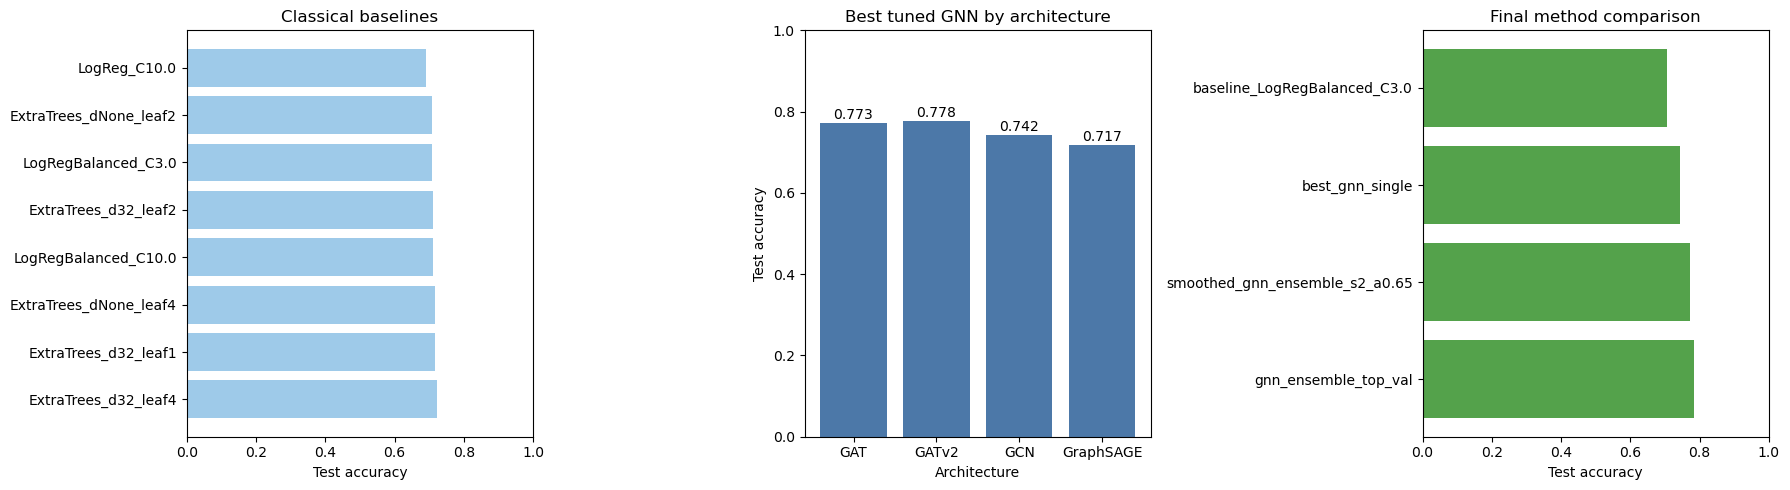

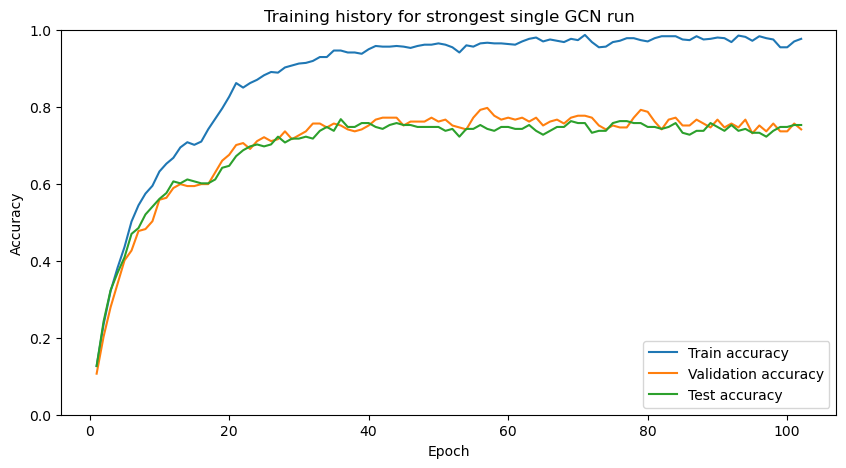

In [210]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

baseline_plot = baseline_results_df.head(8).sort_values("test_accuracy", ascending=False)
axes[0].barh(baseline_plot["method"], baseline_plot["test_accuracy"], color="#9ecae9")
axes[0].set_title("Classical baselines")
axes[0].set_xlabel("Test accuracy")
axes[0].set_xlim(0, 1)

arch_plot = best_by_architecture.sort_values("model")
axes[1].bar(arch_plot["model"], arch_plot["test_accuracy"], color="#4c78a8")
axes[1].set_title("Best tuned GNN by architecture")
axes[1].set_xlabel("Architecture")
axes[1].set_ylabel("Test accuracy")
axes[1].set_ylim(0, 1)
for index, row in arch_plot.reset_index(drop=True).iterrows():
    axes[1].text(index, row["test_accuracy"] + 0.01, f"{row['test_accuracy']:.3f}", ha="center")

method_plot = comparison_df.sort_values("test_accuracy", ascending=False)
axes[2].barh(method_plot["method"], method_plot["test_accuracy"], color="#54a24b")
axes[2].set_title("Final method comparison")
axes[2].set_xlabel("Test accuracy")
axes[2].set_xlim(0, 1)

plt.tight_layout()
plt.show()

history = best_run.get("history")
if history is not None:
    plt.figure(figsize=(10, 5))
    plt.plot(history["epoch"], history["train_accuracy"], label="Train accuracy")
    plt.plot(history["epoch"], history["val_accuracy"], label="Validation accuracy")
    plt.plot(history["epoch"], history["test_accuracy"], label="Test accuracy")
    plt.title(f"Training history for strongest single {best_run['model']} run")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1)
    plt.legend()
    plt.show()


### Selected Final Method Evaluation


In [211]:
y_test = data.y[data.test_mask].detach().cpu().numpy()
y_test_pred = best_run["predictions"][data.test_mask].detach().cpu().numpy()

print("Selected final method:", best_run.get("final_method", best_run["model"]))
print("Confusion matrix on test nodes:")
print(confusion_matrix(y_test, y_test_pred))

print("Classification report on test nodes:")
print(classification_report(y_test, y_test_pred, zero_division=0))


Selected final method: best_gnn_single
Confusion matrix on test nodes:
[[ 9  0  0 ...  0  0  0]
 [ 0 11  0 ...  0  0  0]
 [ 0  0  2 ...  0  0  0]
 ...
 [ 0  0  0 ...  3  1  0]
 [ 0  0  0 ...  0  3  0]
 [ 0  0  0 ...  0  0  2]]
Classification report on test nodes:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86        10
           1       1.00      0.85      0.92        13
           2       1.00      1.00      1.00         2
           3       0.67      1.00      0.80         2
           4       0.82      0.82      0.82        22
           5       0.80      1.00      0.89         4
           6       0.33      0.50      0.40         6
           7       0.88      0.70      0.78        10
           8       0.57      1.00      0.73         4
           9       1.00      0.57      0.73         7
          10       0.86      0.75      0.80         8
          11       0.67      1.00      0.80         6
          12       0.67      0.80

### Prediction Visualization On A Subgraph


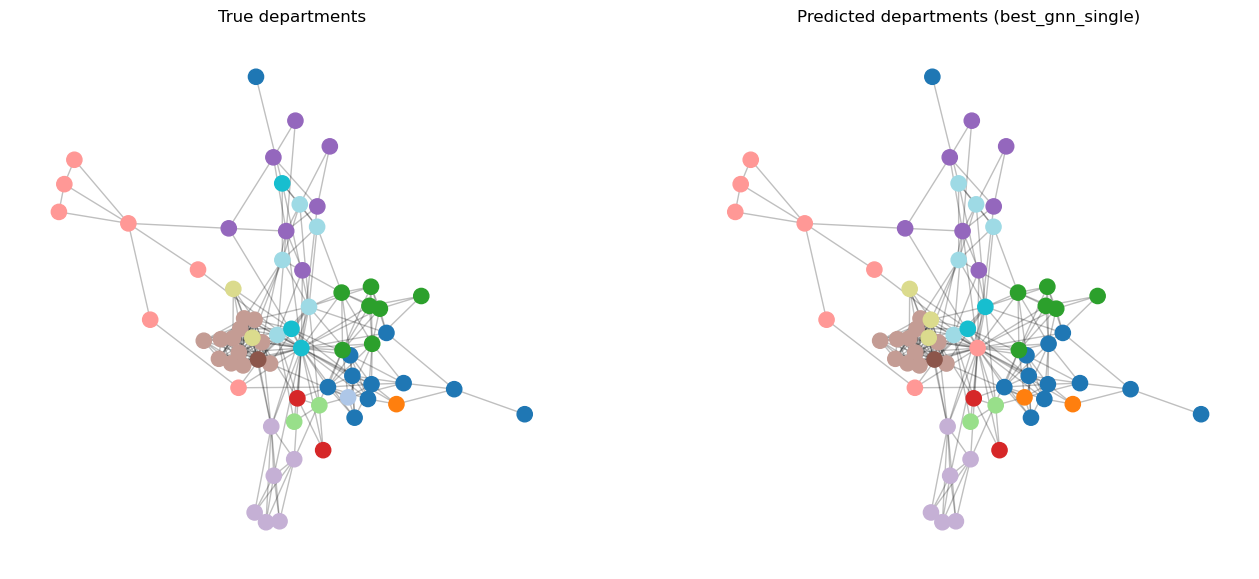

In [212]:
predictions = best_run["predictions"]
idx_to_node_id = {idx: node_id for node_id, idx in node_id_to_idx.items()}

test_indices = test_mask.nonzero(as_tuple=True)[0].tolist()
random.seed(42)
center_indices = random.sample(test_indices, min(12, len(test_indices)))
center_nodes = [idx_to_node_id[idx] for idx in center_indices]

visual_nodes = set(center_nodes)
for node in center_nodes:
    visual_nodes.update(list(G.predecessors(node))[:4])
    visual_nodes.update(list(G.successors(node))[:4])

visual_nodes = list(visual_nodes)[:90]
visual_subgraph = G.subgraph(visual_nodes).to_undirected().copy()
pos = nx.spring_layout(visual_subgraph, seed=42)

true_colors = [
    class_to_idx.get(node_to_label.get(node, -1), -1)
    for node in visual_subgraph.nodes()
]
pred_colors = [
    predictions[node_id_to_idx[node]].item()
    if node_id_to_idx[node] in valid_indices.tolist()
    else -1
    for node in visual_subgraph.nodes()
]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, colors, title in zip(
    axes,
    [true_colors, pred_colors],
    ["True departments", f"Predicted departments ({best_run.get('final_method', best_run['model'])})"],
):
    nx.draw_networkx_nodes(
        visual_subgraph,
        pos,
        node_size=120,
        node_color=colors,
        cmap=plt.cm.tab20,
        ax=ax,
    )
    nx.draw_networkx_edges(
        visual_subgraph,
        pos,
        alpha=0.25,
        ax=ax,
    )
    ax.set_title(title)
    ax.axis("off")

plt.show()
